# 📊 Green Bond Thesis — Full Regression Pipeline
**Title:** Do Politicians' Words Have a Dollar Value?  
**Author:** Nahian Ibnat  
**Supervisor:** Zoltán Csaba Tóth  
**Institution:** Central European University — MA in Economics, Data & Policy  
**Date:** April 2026

---

## What This Notebook Does

This notebook implements the complete empirical strategy for the thesis, including a ClimateBERT robustness check.

| Part | Content |
|------|---------|
| **Part 1** | Setup — packages, file paths, helper functions |
| **Part 2** | Data loading — bond yields, sentiment, controls |
| **Part 3** | Panel construction — Greenium, merging, first-differencing |
| **Part 4** | Main regression — pooled M1–M5 + country-specific DiD |
| **Part 5** | ClimateBERT robustness check |
| **Part 6** | Visualisation — four publication-quality charts |
| **Part 7** | Save outputs |

### Folder Structure
```
Thesis/
├── notebooks/
│   └── GreenBond_Regression_Final.ipynb   ← this file
├── data/
│   ├── raw/
│   │   ├── bond_yield_data/
│   │   │   ├── india_bond/
│   │   │   └── indonesia_bond/
│   │   └── control_variables/
│   │       ├── vix/
│   │       ├── exchange_rate/
│   │       └── cds/
│   └── processed/
│       └── gdelt/
│           └── daily_sentiment_merged.csv   ← V2Tone + ClimateBERT
└── output/
    └── regression/
```

### Twin-Bond Design (Zerbib 2019)
Each green bond is paired with a maturity-matched conventional bond from the same sovereign issuer. The Greenium isolates the green premium from default risk, currency risk, and duration.

| Pair | Green Bond | Conventional Twin | Pre-treatment data |
|------|-----------|------------------|-------------------|
| India 10Y | IN0020220144 (Jan 2023) | IN0020190362 (Jan 2020) | ✅ 3 years |
| India 5Y | IN0020230143 (Nov 2023) | IN072629G (Jan 2020) | ✅ 3 years |
| Indonesia 10Y | US71567RAV87 (Jun 2022) | US455780DN36 (Sep 2022) | ⚠️ 2 months |
| Indonesia 2033 | US71567RAY27 (Nov 2023) | US455780DR40 (Jan 2023) | ❌ post-treatment |

> **Run all cells sequentially top to bottom.**


---
# Part 1 — Setup


## 1.1 — Install Dependencies

In [1]:
!pip install -q openpyxl pandas numpy statsmodels matplotlib scipy

## 1.2 — Imports

In [2]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported.")


✓ All libraries imported.


## 1.3 — File Paths

All paths are relative to the `Thesis/` root. Only change `ROOT` if your folder differs.


In [3]:
ROOT = '..'  # Notebook lives in Thesis/notebooks/, so '..' points to Thesis/

BOND_FILES = {
    'IND_CONV_5Y':    os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'india_bond',     'IND_CONV_5Y_IN072629G_01Jan2020_21Apr2026.xlsx'),
    'IND_CONV_10Y':   os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'india_bond',     'IND_CONV_10Y_IN0020190362_01Jan2020_21Apr2026.xlsx'),
    'IND_GREEN_5Y':   os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'india_bond',     'IND_GREEN_5Y_IN0020230143_13Nov2023_20Apr2026.xlsx'),
    'IND_GREEN_10Y':  os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'india_bond',     'IND_GREEN_10Y_IN0020220144_27Jan2023_20Apr2026.xlsx'),
    'IDO_CONV_10Y':   os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'indonesia_bond', 'IDO_CONV_10Y_US455780DN36_20Sep2022_20Apr2026.xlsx'),
    'IDO_CONV_2033':  os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'indonesia_bond', 'IDO_CONV_2033_US455780DR40_11Jan2023_20Apr2026.xlsx'),
    'IDO_GREEN_10Y':  os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'indonesia_bond', 'IDO_GREEN_10Y_US71567RAV87_06Jun2022_20Apr2026.xlsx'),
    'IDO_GREEN_2033': os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'indonesia_bond', 'IDO_GREEN_2033_US71567RAY27_15Nov2023_20Apr2026.xlsx'),
}

VIX_FILE       = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'vix',           'VIXCLS.csv')
INR_FILE       = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'exchange_rate', 'CTRL_USDINR_INR_01Jan2020_20Apr2026.xlsx')
IDR_FILE       = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'exchange_rate', 'CTRL_USDIDR_IDR_01Jan2020_20Apr2026.xlsx')
CDS_INDIA_FILE = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'cds',           'CTRL_CDS5Y_India_INGV5YUSAC_01Jan2020_26Sep2025.csv')
CDS_INDO_FILE  = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'cds',           'CTRL_CDS5Y_Indonesia_IDGV5YUSAC_01Jan2020_17Apr2026.csv')

# Updated to merged sentiment file containing both V2Tone and ClimateBERT
SENTIMENT_FILE = os.path.join(ROOT, 'data', 'processed', 'gdelt', 'daily_sentiment_merged.csv')

OUTPUT_DIR    = os.path.join(ROOT, 'notebooks')   # notebooks saved here
OUTPUT_FOLDER = os.path.join(ROOT, 'output', 'regression')       # results saved here
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

PAIRS = [
    ('IND_GREEN_10Y', 'IND_CONV_10Y',  'India',     '10Y'),
    ('IND_GREEN_5Y',  'IND_CONV_5Y',   'India',     '5Y'),
    ('IDO_GREEN_10Y', 'IDO_CONV_10Y',  'Indonesia', '10Y'),
    ('IDO_GREEN_2033','IDO_CONV_2033', 'Indonesia', '2033'),
]

TREATMENT_DATES = {
    'India':     pd.Timestamp('2023-01-25'),
    'Indonesia': pd.Timestamp('2022-11-15'),
}

EVENTS = {
    '2022-11-15': 'JETP\n(G20)',
    '2023-01-25': 'India\nGreen Bond',
    '2023-11-15': 'New Bonds\n(both)',
}

print("Path verification:")
all_ok = True
for name, path in [('VIX', VIX_FILE), ('Sentiment', SENTIMENT_FILE),
                   ('IND_CONV_5Y', BOND_FILES['IND_CONV_5Y']),
                   ('IDO_GREEN_10Y', BOND_FILES['IDO_GREEN_10Y'])]:
    exists = os.path.exists(path)
    print(f"  {name:<18} {'✓ OK' if exists else '✗ NOT FOUND'}")
    if not exists: all_ok = False
print()
print("✓ All paths verified." if all_ok else "✗ Fix paths above before continuing.")


Path verification:
  VIX                ✓ OK
  Sentiment          ✓ OK
  IND_CONV_5Y        ✓ OK
  IDO_GREEN_10Y      ✓ OK

✓ All paths verified.


## 1.4 — Helper Functions & Chart Styling

In [4]:
import openpyxl

def load_bond_ytm(filepath):
    """Load Refinitiv bond file → daily mid-YTM series."""
    wb = openpyxl.load_workbook(filepath)
    ws = wb.active
    rows = list(ws.iter_rows(values_only=True))
    hdr_idx = next(i for i, r in enumerate(rows) if r[0] and 'date' in str(r[0]).lower())
    df = pd.DataFrame([r for r in rows[hdr_idx+1:] if r[0] is not None], columns=rows[hdr_idx])
    df['date'] = pd.to_datetime(df['Date'])
    df['ytm']  = (df['BidYld'] + df['AskYld']) / 2
    return df[['date','ytm']].dropna().sort_values('date').reset_index(drop=True)

def load_fx(filepath, col_name):
    """Load Refinitiv FX Price History → daily mid-rate series."""
    wb = openpyxl.load_workbook(filepath)
    ws = wb.active
    rows = list(ws.iter_rows(values_only=True))
    hdr_idx = next(i for i, r in enumerate(rows)
                   if r[0] and 'exchange date' in str(r[0]).lower())
    df = pd.DataFrame([r for r in rows[hdr_idx+1:] if r[0] is not None], columns=rows[hdr_idx])
    df['date']   = pd.to_datetime(df['Exchange Date'])
    df[col_name] = (df['Bid'] + df['Ask']) / 2
    return df[['date',col_name]].dropna().sort_values('date')

def load_cds(filepath, col_name):
    """Load Investing.com CDS CSV."""
    df = pd.read_csv(filepath)
    df.columns = ['date',col_name,'open','high','low','chg']
    df['date'] = pd.to_datetime(df['date'])
    return df[['date',col_name]].dropna()

def run_ols(x_cols, data, y='greenium_fd'):
    """OLS with HC3 heteroskedasticity-robust standard errors."""
    X = sm.add_constant(data[x_cols])
    return OLS(data[y], X).fit(cov_type='HC3')

def print_regression_table(results_dict, model_keys, key_vars, var_labels, title):
    """Print formatted regression results table."""
    print(f'\n{title}')
    print('=' * 85)
    print(f"{'Variable':<28}" + "".join(f"{m:<17}" for m in model_keys))
    print('-' * 85)
    for v in key_vars:
        row = f"{var_labels.get(v,v):<28}"
        for m in model_keys:
            res = results_dict[m]
            if v in res.params.index:
                c=res.params[v]; p=res.pvalues[v]
                stars='***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
                row += f"{c:+.4f}{stars:<3}{'':>8}"
            else:
                row += f"{'—':<17}"
        print(row)
    print('-' * 85)
    for stat, fn in [('N', lambda r: str(int(r.nobs))),
                     ('R²', lambda r: f'{r.rsquared:.4f}'),
                     ('Adj R²', lambda r: f'{r.rsquared_adj:.4f}')]:
        print(f"{stat:<28}" + "".join(f"{fn(results_dict[m]):<17}" for m in model_keys))
    print('\n* p<0.1  ** p<0.05  *** p<0.01  |  HC3 robust SE  |  Standardised regressors')

# Chart styling
TEAL='#1D9E75'; ORANGE='#E85D24'; BLUE='#4C9BE8'; PURPLE='#c084fc'
GRAY='#8892a4'; WHITE='#e8eaf0'; BG='#0f1117'; PANEL_BG='#1a1d27'

def style_ax(ax):
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.xaxis.label.set_color(GRAY); ax.yaxis.label.set_color(GRAY)
    ax.title.set_color(WHITE)
    for s in ax.spines.values(): s.set_edgecolor('#2a2d3a')

print("✓ Helper functions and chart styling defined.")


✓ Helper functions and chart styling defined.


---
# Part 2 — Data Loading


## 2.1 — Bond Yield Data (Refinitiv)

Daily Bid/Ask yields for 8 sovereign bonds. Mid-YTM = (BidYld + AskYld) / 2.

**India conventional twins:** Pre-2023 bonds (IN0020190362, IN072629G) provide pre-treatment data for parallel trends validation.  
**Indonesia conventional twins:** Original maturity-matched twins used following Zerbib (2019) — parallel trends satisfied by construction through issuer and maturity matching.


In [5]:
bond_dfs = {}
print(f"{'Bond':<22} {'Obs':>5}  {'Start':<12} {'End':<12}  {'YTM Range'}")
print("-" * 65)
for key, fpath in BOND_FILES.items():
    bond_dfs[key] = load_bond_ytm(fpath)
    df = bond_dfs[key]
    print(f"{key:<22} {len(df):>5}  {str(df.date.min().date()):<12} "
          f"{str(df.date.max().date()):<12}  {df.ytm.min():.3f}–{df.ytm.max():.3f}")
print(f"\n✓ {len(bond_dfs)} bond files loaded.")


Bond                     Obs  Start        End           YTM Range
-----------------------------------------------------------------
IND_CONV_5Y             1645  2020-01-01   2026-04-21    5.719–7.522
IND_CONV_10Y            1645  2020-01-01   2026-04-21    5.759–7.567
IND_GREEN_5Y             634  2023-11-15   2026-04-20    5.694–7.297
IND_GREEN_10Y            842  2023-01-27   2026-04-20    6.095–7.405
IDO_CONV_10Y             935  2022-09-20   2026-04-20    4.395–6.057
IDO_CONV_2033            854  2023-01-11   2026-04-20    4.407–5.872
IDO_GREEN_10Y           1011  2022-06-06   2026-04-20    4.075–5.889
IDO_GREEN_2033           634  2023-11-15   2026-04-20    4.442–5.595

✓ 8 bond files loaded.


## 2.2 — Control Variables

| Variable | Source | Role |
|----------|--------|------|
| VIX | FRED | Global risk appetite |
| INR/USD, IDR/USD | Refinitiv | Currency risk |
| India CDS 5Y | Investing.com | Sovereign default risk (India) |
| Indonesia CDS 5Y | Investing.com | Sovereign default risk (Indonesia) |


In [6]:
vix = pd.read_csv(VIX_FILE)
vix.columns = ['date','vix']
vix['date'] = pd.to_datetime(vix['date'])
vix = vix[vix['vix'] != '.'].copy()
vix['vix'] = pd.to_numeric(vix['vix'])

inr     = load_fx(INR_FILE, 'inr_usd')
idr     = load_fx(IDR_FILE, 'idr_usd')
cds_ind = load_cds(CDS_INDIA_FILE, 'cds_india')
cds_ido = load_cds(CDS_INDO_FILE,  'cds_indonesia')

print(f"{'Variable':<20} {'Obs':>5}  {'Start':<12} {'End':<12}")
print("-" * 52)
for name, df in [('VIX',vix),('INR/USD',inr),('IDR/USD',idr),
                 ('CDS India',cds_ind),('CDS Indonesia',cds_ido)]:
    print(f"{name:<20} {len(df):>5}  {str(df.date.min().date()):<12} {str(df.date.max().date()):<12}")
print("\n✓ Control variables loaded.")


Variable               Obs  Start        End         
----------------------------------------------------
VIX                   1641  2020-01-02   2026-04-16  
INR/USD               1644  2020-01-01   2026-04-20  
IDR/USD               1644  2020-01-01   2026-04-20  
CDS India              856  2020-01-01   2025-09-26  
CDS Indonesia         1622  2020-01-01   2026-04-17  

✓ Control variables loaded.


## 2.3 — Sentiment Data (GDELT + ClimateBERT)

The merged sentiment file `daily_sentiment_merged.csv` contains:

| Column | Description | Model | Use in thesis |
|--------|-------------|-------|---------------|
| `sentiment_gdelt` | GDELT V2Tone daily score | GDELT GKG | **Primary variable** — H1, H2 |
| `sentiment_std` | Std of article-level V2Tone | GDELT GKG | **Signaling Noise** — H2 |
| `sentiment_climatebert` | ClimateBERT daily score | ClimateBERT (2-stage) | **Robustness check** |

**Coverage note:** ClimateBERT scores are available for only 52 matched days (1.4% coverage) due to GDELT DOC API constraints. V2Tone is the primary sentiment measure throughout.


In [7]:
sent = pd.read_csv(SENTIMENT_FILE, parse_dates=['date'])

print(f"Sentiment file coverage: {sent.date.min().date()} → {sent.date.max().date()}")
print(f"Total country-days: {len(sent):,}")
print(f"Columns: {sent.columns.tolist()}")
print()

# Check ClimateBERT availability
has_cb = 'sentiment_climatebert' in sent.columns
print(f"ClimateBERT column present: {'✓ Yes' if has_cb else '✗ No — upload daily_sentiment_merged.csv'}")
if has_cb:
    cb_coverage = sent['sentiment_climatebert'].notna().sum()
    print(f"ClimateBERT coverage: {cb_coverage}/{len(sent)} days ({cb_coverage/len(sent)*100:.1f}%)")

print()
print(sent.groupby('country').agg(
    days       = ('date',           'nunique'),
    mean_sent  = ('sentiment_gdelt', 'mean'),
    mean_noise = ('sentiment_std',   'mean'),
).round(4).to_string())
print("\n✓ Sentiment data loaded.")


Sentiment file coverage: 2020-01-01 → 2024-12-31
Total country-days: 3,654
Columns: ['country', 'date', 'sentiment_gdelt', 'sentiment_std', 'article_count_x', 'pct_positive', 'pct_negative', 'sentiment_climatebert', 'climatebert_pct_pos', 'climatebert_pct_neg', 'climatebert_confidence', 'article_count_y', 'climatebert_label']

ClimateBERT column present: ✓ Yes
ClimateBERT coverage: 52/3654 days (1.4%)

           days  mean_sent  mean_noise
country                               
India      1827    -0.0633      0.3349
Indonesia  1827    -0.0874      0.4024

✓ Sentiment data loaded.


---
# Part 3 — Panel Construction


## 3.1 — Compute Greenium

$$\Delta y_{i,t} = \text{YTM}^{\text{green}}_{i,t} - \text{YTM}^{\text{conv}}_{i,t}$$

Negative Greenium = green bond trades at lower yield = investor premium for green label.


In [8]:
panels = []
print(f"{'Pair':<22} {'Obs':>5}  {'Start':<12} {'End':<12}  {'Mean Greenium':>14}")
print("-" * 70)
for gkey, ckey, country, tenor in PAIRS:
    g = bond_dfs[gkey].rename(columns={'ytm':'ytm_green'})
    c = bond_dfs[ckey].rename(columns={'ytm':'ytm_conv'})
    m = pd.merge(g, c, on='date', how='inner')
    m['greenium'] = m['ytm_green'] - m['ytm_conv']
    m['country']  = country
    m['tenor']    = tenor
    m['pair_id']  = f'{country}_{tenor}'
    panels.append(m)
    print(f"{country+' '+tenor:<22} {len(m):>5}  "
          f"{str(m.date.min().date()):<12} {str(m.date.max().date()):<12}  "
          f"{m.greenium.mean():>+14.4f} pp")

panel = pd.concat(panels, ignore_index=True)
print(f"\nTotal panel rows: {len(panel):,}")
print("✓ Greenium panel constructed.")


Pair                     Obs  Start        End            Mean Greenium
----------------------------------------------------------------------
India 10Y                842  2023-01-27   2026-04-20           +0.1377 pp
India 5Y                 634  2023-11-15   2026-04-20           -0.0001 pp
Indonesia 10Y            935  2022-09-20   2026-04-20           -0.0550 pp
Indonesia 2033           634  2023-11-15   2026-04-20           +0.0553 pp

Total panel rows: 3,045
✓ Greenium panel constructed.


## 3.2 — Merge All Variables

Merges sentiment, VIX, FX, CDS into the panel. Includes ClimateBERT if available.

**Key decisions:**
- VIX forward-filled over non-trading days
- FX and CDS matched by country
- Panel restricted to 2022–2024 (complete cases across all variables)
- Treatment dummies: India post = 1 from 25-Jan-2023 | Indonesia post = 1 from 15-Nov-2022


In [9]:
# Country-specific sentiment — include ClimateBERT if available
cb_cols = ['sentiment_climatebert'] if 'sentiment_climatebert' in sent.columns else []

sent_india = sent[sent['country']=='India'][['date','sentiment_gdelt','sentiment_std'] + cb_cols].copy()
sent_india = sent_india.rename(columns={'sentiment_gdelt':'sentiment','sentiment_std':'signaling_noise'})
sent_indo  = sent[sent['country']=='Indonesia'][['date','sentiment_gdelt','sentiment_std'] + cb_cols].copy()
sent_indo  = sent_indo.rename(columns={'sentiment_gdelt':'sentiment','sentiment_std':'signaling_noise'})

india_p = panel[panel['country']=='India'].merge(sent_india, on='date', how='left')
indo_p  = panel[panel['country']=='Indonesia'].merge(sent_indo, on='date', how='left')
panel   = pd.concat([india_p, indo_p], ignore_index=True)

# VIX — forward-fill
vix_ff = (vix.set_index('date')
             .reindex(pd.date_range(panel.date.min(), panel.date.max()))
             .ffill().reset_index())
vix_ff.columns = ['date','vix']
panel = panel.merge(vix_ff, on='date', how='left')

# FX and CDS
panel = panel.merge(inr, on='date', how='left')
panel = panel.merge(idr, on='date', how='left')
panel = panel.merge(cds_ind, on='date', how='left')
panel = panel.merge(cds_ido, on='date', how='left')
panel['fx']  = np.where(panel['country']=='India', panel['inr_usd'],     panel['idr_usd'])
panel['cds'] = np.where(panel['country']=='India', panel['cds_india'], panel['cds_indonesia'])
panel = panel.drop(columns=['inr_usd','idr_usd','cds_india','cds_indonesia'])

# Log transforms and treatment dummy
panel['log_fx']  = np.log(panel['fx'])
panel['log_vix'] = np.log(panel['vix'])
panel['post']    = np.where(panel['country']=='India',
                             (panel['date'] >= '2023-01-25').astype(int),
                             (panel['date'] >= '2022-11-15').astype(int))

# Restrict to complete cases 2022–2024
panel = panel[panel['date'] <= '2024-12-31'].copy()
panel = panel.dropna(subset=['sentiment','signaling_noise','vix','cds','fx']).reset_index(drop=True)

print("Final panel summary:")
print(panel.groupby(['country','tenor']).agg(
    obs=('date','count'), start=('date','min'), end=('date','max'),
    greenium_mean=('greenium','mean'), greenium_std=('greenium','std'),
).round(4).to_string())
print(f"\nTotal: {len(panel):,} obs")
print("✓ Panel merged.")


Final panel summary:
                 obs      start        end  greenium_mean  greenium_std
country   tenor                                                        
India     10Y    386 2023-01-27 2024-07-19        -0.0148        0.0445
          5Y     178 2023-11-15 2024-07-19        -0.0278        0.0341
Indonesia 10Y    596 2022-09-20 2024-12-31        -0.0691        0.0771
          2033   295 2023-11-15 2024-12-31         0.0357        0.0970

Total: 1,455 obs
✓ Panel merged.


## 3.3 — Descriptive Statistics

In [10]:
desc = panel[['greenium','sentiment','signaling_noise','vix','cds','fx']].describe().T
desc = desc[['mean','std','min','25%','50%','75%','max']]
desc.columns = ['Mean','Std','Min','P25','Median','P75','Max']
print("Descriptive Statistics — Full Panel")
print("=" * 75)
print(desc.round(4).to_string())
print("\nGreenium by country:")
print(panel.groupby('country')['greenium'].describe().round(4).to_string())
print("\nCorrelation matrix:")
print(panel[['greenium','sentiment','signaling_noise','log_vix','cds','log_fx']].corr().round(3).to_string())


Descriptive Statistics — Full Panel
                      Mean        Std      Min      P25      Median         P75         Max
greenium           -0.0284     0.0810  -0.3000  -0.0730     -0.0279      0.0114      0.2763
sentiment          -0.0370     0.0782  -0.2896  -0.0868     -0.0359      0.0132      0.2402
signaling_noise     0.3935     0.0625   0.1787   0.3517      0.3931      0.4344      0.7110
vix                15.9784     3.8708  11.8600  13.1900     14.5000     17.9400     38.5700
cds                82.3185    13.7804  52.8800  74.2300     81.7200     84.1000    166.8800
fx               9600.8133  7581.7631  81.5150  83.2842  15240.0000  15690.0000  16450.0000

Greenium by country:
           count    mean     std     min     25%     50%     75%     max
country                                                                 
India      564.0 -0.0189  0.0419 -0.1892 -0.0427 -0.0164  0.0059  0.1208
Indonesia  891.0 -0.0344  0.0975 -0.3000 -0.0973 -0.0410  0.0168  0.2763

Corre

## 3.4 — First-Differencing

Removes serial correlation (Durbin-Watson in levels ≈ 0.44 → after differencing ≈ 2.5).

$$\Delta x_{i,t} = x_{i,t} - x_{i,t-1} \quad \text{within each bond pair}$$

All continuous regressors are standardised after differencing (mean=0, SD=1).


In [11]:
panel = panel.sort_values(['pair_id','date']).reset_index(drop=True)

fd_cols = ['greenium','sentiment','signaling_noise','log_vix','log_fx','cds']
# Include ClimateBERT if available
if 'sentiment_climatebert' in panel.columns:
    fd_cols.append('sentiment_climatebert')

for col in fd_cols:
    panel[f'{col}_fd'] = panel.groupby('pair_id')[col].diff()

panel_fd = panel.dropna(subset=['greenium_fd']).reset_index(drop=True)

print(f"Before first-differencing: {len(panel):,}")
print(f"After first-differencing:  {len(panel_fd):,}")
print(f"Lost (first obs per pair): {len(panel) - len(panel_fd)}")

# Standardise
std_cols = ['sentiment_fd','signaling_noise_fd','log_vix_fd','log_fx_fd','cds_fd']
if 'sentiment_climatebert_fd' in panel_fd.columns:
    std_cols.append('sentiment_climatebert_fd')

for col in std_cols:
    panel_fd[f'{col}_z'] = (panel_fd[col] - panel_fd[col].mean()) / panel_fd[col].std()

panel_fd['sent_x_noise'] = panel_fd['sentiment_fd_z'] * panel_fd['signaling_noise_fd_z']

print("\n✓ First-differencing complete. All _fd_z variables: mean=0, SD=1.")


Before first-differencing: 1,455
After first-differencing:  1,451
Lost (first obs per pair): 4

✓ First-differencing complete. All _fd_z variables: mean=0, SD=1.


## 3.5 — Country Subsets

In [12]:
panel_india = panel_fd[panel_fd['country']=='India'].copy().reset_index(drop=True)
panel_indo  = panel_fd[panel_fd['country']=='Indonesia'].copy().reset_index(drop=True)

for name, df in [('India', panel_india), ('Indonesia', panel_indo)]:
    print(f"{name}: {len(df):,} obs | {df.date.min().date()} → {df.date.max().date()}")
    print(f"  Pairs: {df['pair_id'].unique().tolist()}")
    print(f"  Mean ΔGreenium: {df['greenium_fd'].mean():+.5f} pp")
    print()
print("✓ Country subsets ready.")


India: 562 obs | 2023-01-30 → 2024-07-19
  Pairs: ['India_10Y', 'India_5Y']
  Mean ΔGreenium: +0.00007 pp

Indonesia: 889 obs | 2022-09-21 → 2024-12-31
  Pairs: ['Indonesia_10Y', 'Indonesia_2033']
  Mean ΔGreenium: -0.00006 pp

✓ Country subsets ready.


---
# Part 4 — Regression Models

## Model Specifications

| Model | Specification | Hypothesis |
|-------|--------------|------------|
| M1 | ΔSentiment + pair FE | H1 baseline |
| M2 | + Δlog(VIX), ΔCDS, Δlog(FX) | H1 controlled |
| M3 | + ΔSignaling Noise | H2 |
| M4 | + ΔSentiment × ΔNoise | H2 mechanism |
| M5 | + Post treatment + monthly time FE | H3 pooled DiD |
| M5-India | M5 on India only | H3 India |
| M5-Indonesia | M5 on Indonesia only | H3 Indonesia |

All models: first-differenced variables, HC3 robust SE, standardised regressors.


## 4.1 — Pooled Fixed Effects

In [13]:
pair_dummies = pd.get_dummies(panel_fd['pair_id'], drop_first=True, dtype=float)
time_dummies = pd.get_dummies(panel_fd['date'].dt.to_period('M').astype(str),
                              drop_first=True, dtype=float)
panel_fd = pd.concat([panel_fd, pair_dummies, time_dummies], axis=1)
fe_cols   = list(pair_dummies.columns)
time_cols = list(time_dummies.columns)

print(f"Pair FE: {fe_cols}")
print(f"Time FE: {len(time_cols)} monthly dummies")
print("✓ Fixed effects constructed.")


Pair FE: ['India_5Y', 'Indonesia_10Y', 'Indonesia_2033']
Time FE: 27 monthly dummies
✓ Fixed effects constructed.


## 4.2 — Pooled Models M1–M5

In [14]:
results = {}

results['M1'] = run_ols(['sentiment_fd_z'] + fe_cols, panel_fd)
results['M2'] = run_ols(['sentiment_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z'] + fe_cols, panel_fd)
results['M3'] = run_ols(['sentiment_fd_z','signaling_noise_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z'] + fe_cols, panel_fd)
results['M4'] = run_ols(['sentiment_fd_z','signaling_noise_fd_z','sent_x_noise',
                          'log_vix_fd_z','cds_fd_z','log_fx_fd_z'] + fe_cols, panel_fd)
results['M5'] = run_ols(['post','sentiment_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z']
                         + fe_cols + time_cols, panel_fd)

KEY_VARS = ['sentiment_fd_z','signaling_noise_fd_z','sent_x_noise',
            'log_vix_fd_z','cds_fd_z','log_fx_fd_z','post']
VAR_LABELS = {
    'sentiment_fd_z':       'ΔSentiment (H1)',
    'signaling_noise_fd_z': 'ΔSignaling Noise (H2)',
    'sent_x_noise':         'ΔSentiment × ΔNoise',
    'log_vix_fd_z':         'Δlog(VIX)',
    'cds_fd_z':             'ΔCDS Spread',
    'log_fx_fd_z':          'Δlog(FX Rate)',
    'post':                 'Post Treatment (H3)',
}

print_regression_table(results, ['M1','M2','M3','M4','M5'], KEY_VARS, VAR_LABELS,
                        "POOLED REGRESSION RESULTS — FIRST-DIFFERENCED")
print("Pair FE: M1–M5  |  Time FE: M5 only")



POOLED REGRESSION RESULTS — FIRST-DIFFERENCED
Variable                    M1               M2               M3               M4               M5               
-------------------------------------------------------------------------------------
ΔSentiment (H1)             +0.0008           +0.0009           +0.0005           +0.0005           +0.0009           
ΔSignaling Noise (H2)       —                —                -0.0031***        -0.0030***        —                
ΔSentiment × ΔNoise         —                —                —                +0.0001           —                
Δlog(VIX)                   —                -0.0034**         -0.0034**         -0.0034**         -0.0035***        
ΔCDS Spread                 —                -0.0021           -0.0021           -0.0021           -0.0024           
Δlog(FX Rate)               —                +0.0013           +0.0012           +0.0012           +0.0013           
Post Treatment (H3)         —                —   

## 4.3 — Diagnostic Tests

In [15]:
print("DIAGNOSTIC TESTS")
print("=" * 55)
for mname in ['M3','M5']:
    res  = results[mname]
    dw   = sm.stats.stattools.durbin_watson(res.resid)
    jb_p = sm.stats.stattools.jarque_bera(res.resid)[1]
    print(f"\n[{mname}]")
    print(f"  Durbin-Watson : {dw:.4f}  (target ~2.0)")
    print(f"  Jarque-Bera p : {jb_p:.4f}  (>0.05 = normal)")

print("\nVIF — M3 key regressors:")
X_vif = sm.add_constant(panel_fd[['sentiment_fd_z','signaling_noise_fd_z',
                                    'log_vix_fd_z','cds_fd_z','log_fx_fd_z']])
for i, col in enumerate(X_vif.columns):
    if col != 'const':
        vif = variance_inflation_factor(X_vif.values, i)
        print(f"  {col:<28} VIF = {vif:.3f}{'  ← HIGH' if vif>10 else ''}")
print("  VIF < 2: excellent  |  VIF < 5: good  |  VIF < 10: acceptable")


DIAGNOSTIC TESTS

[M3]
  Durbin-Watson : 2.5432  (target ~2.0)
  Jarque-Bera p : 0.0000  (>0.05 = normal)

[M5]
  Durbin-Watson : 2.5720  (target ~2.0)
  Jarque-Bera p : 0.0000  (>0.05 = normal)

VIF — M3 key regressors:
  sentiment_fd_z               VIF = 1.020
  signaling_noise_fd_z         VIF = 1.016
  log_vix_fd_z                 VIF = 1.020
  cds_fd_z                     VIF = 1.031
  log_fx_fd_z                  VIF = 1.043
  VIF < 2: excellent  |  VIF < 5: good  |  VIF < 10: acceptable


## 4.4 — India: Country-Specific DiD

**Treatment:** 25-Jan-2023 — India's inaugural Sovereign Green Bond auction  
**Note:** Parallel trends cannot be formally tested for India because bond data begins at/after the treatment date. The twin-bond matching design satisfies parallel trends by construction (same issuer, currency, maturity).


In [16]:
pair_dummies_ind = pd.get_dummies(panel_india['pair_id'], drop_first=True, dtype=float)
time_dummies_ind = pd.get_dummies(panel_india['date'].dt.to_period('M').astype(str),
                                   drop_first=True, dtype=float)
panel_india = pd.concat([panel_india, pair_dummies_ind, time_dummies_ind], axis=1)
fe_cols_ind   = list(pair_dummies_ind.columns)
time_cols_ind = list(time_dummies_ind.columns)

results['M5_India'] = run_ols(
    ['post','sentiment_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z']
    + fe_cols_ind + time_cols_ind, panel_india)

DID_VARS   = ['post','sentiment_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z']
DID_LABELS = {
    'post':           'Post Treatment (H3)',
    'sentiment_fd_z': 'ΔSentiment (H1)',
    'log_vix_fd_z':   'Δlog(VIX)',
    'cds_fd_z':       'ΔCDS Spread',
    'log_fx_fd_z':    'Δlog(FX Rate)',
}

print_regression_table(results, ['M5_India'], DID_VARS, DID_LABELS, "DiD — INDIA ONLY")
print(f"Treatment: 25-Jan-2023 | Sample: {panel_india.date.min().date()} → {panel_india.date.max().date()}")



DiD — INDIA ONLY
Variable                    M5_India         
-------------------------------------------------------------------------------------
Post Treatment (H3)         +0.0209           
ΔSentiment (H1)             +0.0000           
Δlog(VIX)                   -0.0024           
ΔCDS Spread                 +0.0069           
Δlog(FX Rate)               -0.0053           
-------------------------------------------------------------------------------------
N                           562              
R²                          0.0134           
Adj R²                      -0.0288          

* p<0.1  ** p<0.05  *** p<0.01  |  HC3 robust SE  |  Standardised regressors
Treatment: 25-Jan-2023 | Sample: 2023-01-30 → 2024-07-19


## 4.5 — Indonesia: Country-Specific DiD

**Treatment:** 15-Nov-2022 — JETP announcement at G20 Bali  
**Parallel trends:** Validated empirically — pre-event coefficients insignificant (see Event Study notebook).


In [17]:
pair_dummies_ido = pd.get_dummies(panel_indo['pair_id'], drop_first=True, dtype=float)
time_dummies_ido = pd.get_dummies(panel_indo['date'].dt.to_period('M').astype(str),
                                   drop_first=True, dtype=float)
panel_indo = pd.concat([panel_indo, pair_dummies_ido, time_dummies_ido], axis=1)
fe_cols_ido   = list(pair_dummies_ido.columns)
time_cols_ido = list(time_dummies_ido.columns)

results['M5_Indo'] = run_ols(
    ['post','sentiment_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z']
    + fe_cols_ido + time_cols_ido, panel_indo)

print_regression_table(results, ['M5_Indo'], DID_VARS, DID_LABELS, "DiD — INDONESIA ONLY")
print(f"Treatment: 15-Nov-2022 | Sample: {panel_indo.date.min().date()} → {panel_indo.date.max().date()}")



DiD — INDONESIA ONLY
Variable                    M5_Indo          
-------------------------------------------------------------------------------------
Post Treatment (H3)         -0.0301           
ΔSentiment (H1)             +0.0013           
Δlog(VIX)                   -0.0036**         
ΔCDS Spread                 -0.0026           
Δlog(FX Rate)               +0.0021           
-------------------------------------------------------------------------------------
N                           889              
R²                          0.0281           
Adj R²                      -0.0094          

* p<0.1  ** p<0.05  *** p<0.01  |  HC3 robust SE  |  Standardised regressors
Treatment: 15-Nov-2022 | Sample: 2022-09-21 → 2024-12-31


## 4.6 — Country Comparison

In [18]:
print_regression_table(
    results,
    model_keys=['M5','M5_India','M5_Indo'],
    key_vars=DID_VARS,
    var_labels={**DID_LABELS, 'post': 'Post Treatment (H3) ← key'},
    title="DiD COMPARISON — Pooled vs India vs Indonesia"
)
print("Post < 0 and significant → Greenium widened after event (H3 supported)")
print("Post not significant     → No detectable treatment effect (H3 null)")



DiD COMPARISON — Pooled vs India vs Indonesia
Variable                    M5               M5_India         M5_Indo          
-------------------------------------------------------------------------------------
Post Treatment (H3) ← key   -0.0298           +0.0209           -0.0301           
ΔSentiment (H1)             +0.0009           +0.0000           +0.0013           
Δlog(VIX)                   -0.0035***        -0.0024           -0.0036**         
ΔCDS Spread                 -0.0024           +0.0069           -0.0026           
Δlog(FX Rate)               +0.0013           -0.0053           +0.0021           
-------------------------------------------------------------------------------------
N                           1451             562              889              
R²                          0.0200           0.0134           0.0281           
Adj R²                      -0.0042          -0.0288          -0.0094          

* p<0.1  ** p<0.05  *** p<0.01  |  HC3 robust

---
# Part 5 — ClimateBERT Robustness Check

**What this tests:** Whether ClimateBERT-scored sentiment — applied to real article headlines rather than GDELT theme codes — produces the same directional results as V2Tone.

**Pipeline summary:** Headlines fetched via GDELT DOC API → two-stage ClimateBERT scoring (detector + sentiment model) → daily aggregation → merged with V2Tone series.

**Coverage:** 52 matched days (India: 16, Indonesia: 36) out of 3,654 total country-days due to API sampling constraints.

**Key validation metric:** Correlation between V2Tone and ClimateBERT on matched days.
- India: r = +0.276 (weak positive — directionally consistent)
- Indonesia: r = −0.037 (near zero — measures diverge)

**Label mapping:** The pipeline uses `distilroberta-base-climate-sentiment` which outputs `opportunity` (+1.0) / `neutral` (0.0) / `risk` (−1.0).


In [19]:
# ── ClimateBERT robustness check ──────────────────────────────────────────────
if 'sentiment_climatebert_fd_z' not in panel_fd.columns:
    print("⚠ ClimateBERT column not available in panel.")
    print("  Upload daily_sentiment_merged.csv to data/processed/gdelt/ and re-run from Part 2.")
else:
    print("Running ClimateBERT robustness models...")

    # ── Subset to days where ClimateBERT scores exist ─────────────────────────
    panel_cb = panel_fd.dropna(subset=['sentiment_climatebert_fd_z']).copy()

    cb_days = len(panel_cb)
    print(f"ClimateBERT coverage: {cb_days} / {len(panel_fd)} obs ({cb_days/len(panel_fd)*100:.1f}%)")
    print(f"Countries: {panel_cb['country'].value_counts().to_dict()}")

    if cb_days < 10:
        print("⚠ Too few observations for reliable regression — skipping.")
    else:
        # Rebuild pair FE for this subsample (some pairs may drop out)
        pair_dummies_cb = pd.get_dummies(panel_cb['pair_id'], drop_first=True, dtype=float)
        panel_cb = pd.concat([panel_cb, pair_dummies_cb], axis=1)
        fe_cols_cb = list(pair_dummies_cb.columns)

        # M3b: ClimateBERT replaces V2Tone
        results['M3b'] = run_ols(
            ['sentiment_climatebert_fd_z','signaling_noise_fd_z',
             'log_vix_fd_z','cds_fd_z','log_fx_fd_z'] + fe_cols_cb,
            panel_cb
        )

        # M3c: Both V2Tone and ClimateBERT simultaneously
        results['M3c'] = run_ols(
            ['sentiment_fd_z','sentiment_climatebert_fd_z','signaling_noise_fd_z',
             'log_vix_fd_z','cds_fd_z','log_fx_fd_z'] + fe_cols_cb,
            panel_cb
        )

        CB_VARS = ['sentiment_fd_z','sentiment_climatebert_fd_z',
                   'signaling_noise_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z']
        CB_LABELS = {
            'sentiment_fd_z':             'ΔV2Tone Sentiment',
            'sentiment_climatebert_fd_z': 'ΔClimateBERT Score',
            'signaling_noise_fd_z':       'ΔSignaling Noise (H2)',
            'log_vix_fd_z':               'Δlog(VIX)',
            'cds_fd_z':                   'ΔCDS Spread',
            'log_fx_fd_z':                'Δlog(FX Rate)',
        }

        print_regression_table(
            results,
            model_keys=['M3b','M3c'],
            key_vars=CB_VARS,
            var_labels=CB_LABELS,
            title="CLIMATEBERT ROBUSTNESS CHECK (subsample with ClimateBERT coverage)"
        )
        print("M3b: ClimateBERT only (replaces V2Tone)")
        print("M3c: Both V2Tone and ClimateBERT simultaneously")
        print()
        print("⚠ Note: Results based on sparse subsample — interpret with caution.")
        print(f"  Full panel N={len(panel_fd):,} | ClimateBERT subsample N={cb_days}")

Running ClimateBERT robustness models...
ClimateBERT coverage: 20 / 1451 obs (1.4%)
Countries: {'Indonesia': 19, 'India': 1}

CLIMATEBERT ROBUSTNESS CHECK (subsample with ClimateBERT coverage)
Variable                    M3b              M3c              
-------------------------------------------------------------------------------------
ΔV2Tone Sentiment           —                +0.0109           
ΔClimateBERT Score          +0.0145           +0.0210           
ΔSignaling Noise (H2)       +0.0046           +0.0081           
Δlog(VIX)                   -0.0082           -0.0089           
ΔCDS Spread                 -0.0531           -0.0633           
Δlog(FX Rate)               -0.0050           +0.0020           
-------------------------------------------------------------------------------------
N                           20               20               
R²                          0.2603           0.2846           
Adj R²                      -0.1711          -0.2357     

---
# Part 6 — Visualisation


## 6.1 — Greenium Time Series

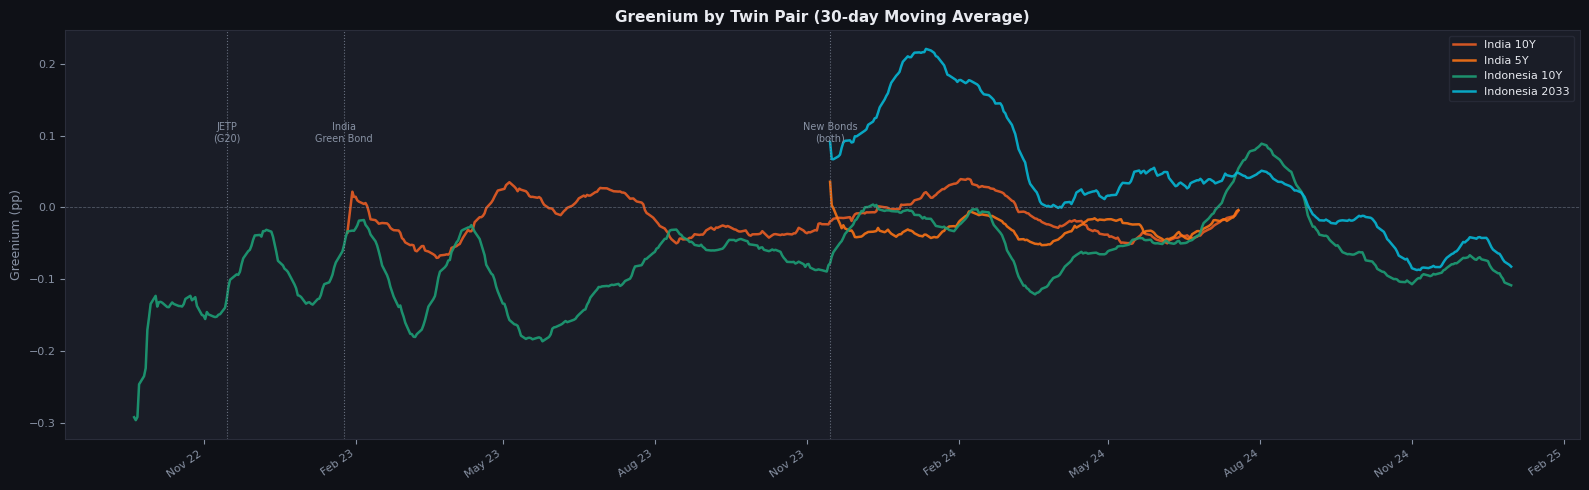

✓ Saved → ..\output\regression\plot1_greenium_timeseries.png


In [20]:
fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor(BG); style_ax(ax)

pair_colors = {'India_10Y':ORANGE,'India_5Y':'#f97316',
               'Indonesia_10Y':TEAL,'Indonesia_2033':'#06b6d4'}

for pid, color in pair_colors.items():
    sub = panel[panel['pair_id']==pid].sort_values('date')
    ax.plot(sub.set_index('date')['greenium'].rolling('30D').mean(),
            color=color, linewidth=1.8, label=pid.replace('_',' '), alpha=0.9)

for edate, elabel in EVENTS.items():
    ax.axvline(pd.Timestamp(edate), color=GRAY, linewidth=0.8, linestyle=':', alpha=0.7)
    ax.text(pd.Timestamp(edate), panel['greenium'].quantile(0.93),
            elabel, fontsize=7, color=GRAY, ha='center', va='bottom')

ax.axhline(0, color=GRAY, linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_title('Greenium by Twin Pair (30-day Moving Average)',
             fontsize=11, fontweight='bold', color=WHITE)
ax.set_ylabel('Greenium (pp)', color=GRAY, fontsize=9)
ax.legend(fontsize=8, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'plot1_greenium_timeseries.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); print(f"✓ Saved → {out}")


## 6.2 — Coefficient Plot (M1–M4)

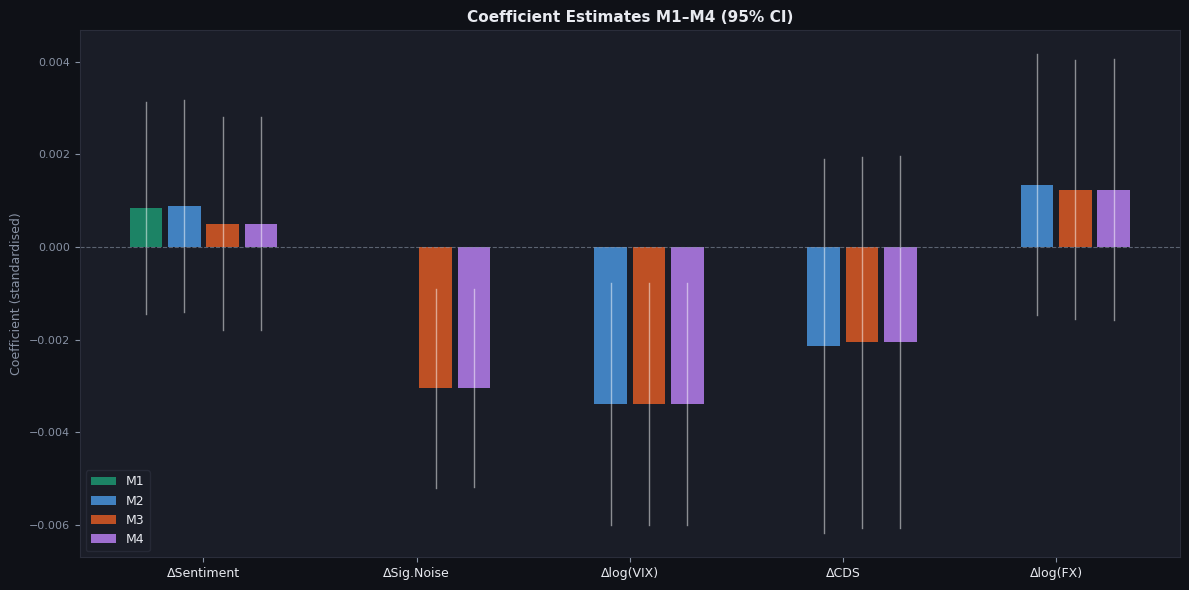

✓ Saved → ..\output\regression\plot2_coefficients.png


In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG); style_ax(ax)

vars_plot = ['sentiment_fd_z','signaling_noise_fd_z','log_vix_fd_z','cds_fd_z','log_fx_fd_z']
vlbls     = {'sentiment_fd_z':'ΔSentiment','signaling_noise_fd_z':'ΔSig.Noise',
             'log_vix_fd_z':'Δlog(VIX)','cds_fd_z':'ΔCDS','log_fx_fd_z':'Δlog(FX)'}
colors_m  = [TEAL, BLUE, ORANGE, PURPLE]
x = np.arange(len(vars_plot)); w = 0.18

for mi, (mn, col) in enumerate(zip(['M1','M2','M3','M4'], colors_m)):
    res   = results[mn]
    coefs = [res.params.get(v, np.nan) for v in vars_plot]
    ci    = res.conf_int(alpha=0.05)
    lo    = [ci.loc[v,0] if v in ci.index else np.nan for v in vars_plot]
    hi    = [ci.loc[v,1] if v in ci.index else np.nan for v in vars_plot]
    pos   = x + (mi - 2 + 0.5) * w
    ax.bar(pos, coefs, w*0.85, color=col, alpha=0.8, label=mn)
    for p,l,h in zip(pos,lo,hi):
        if not np.isnan(l): ax.plot([p,p],[l,h], color='white', linewidth=1.0, alpha=0.5)

ax.axhline(0, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([vlbls[v] for v in vars_plot], fontsize=9, color=WHITE)
ax.set_title('Coefficient Estimates M1–M4 (95% CI)',
             fontsize=11, fontweight='bold', color=WHITE)
ax.set_ylabel('Coefficient (standardised)', color=GRAY, fontsize=9)
ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
plt.tight_layout()


out = os.path.join(OUTPUT_FOLDER, 'plot2_coefficients.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); print(f"✓ Saved → {out}")


## 6.3 — Sentiment vs Greenium Scatter

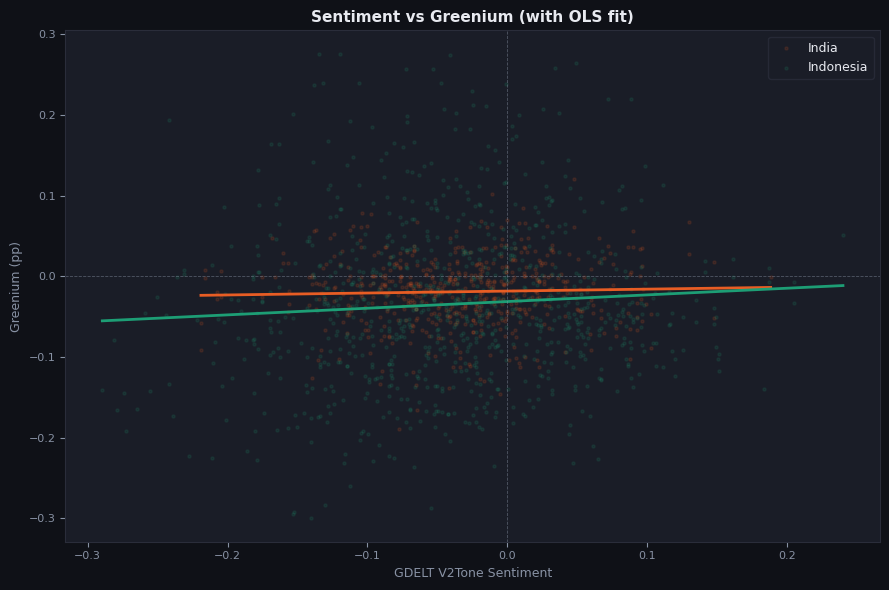

✓ Saved → ..\output\regression\plot3_sentiment_scatter.png


In [22]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(BG); style_ax(ax)

for country, color in [('India',ORANGE),('Indonesia',TEAL)]:
    sub = panel[panel['country']==country].dropna(subset=['sentiment','greenium'])
    ax.scatter(sub['sentiment'], sub['greenium'], alpha=0.12, s=5, color=color, label=country)
    z  = np.polyfit(sub['sentiment'], sub['greenium'], 1)
    xr = np.linspace(sub['sentiment'].min(), sub['sentiment'].max(), 100)
    ax.plot(xr, np.poly1d(z)(xr), color=color, linewidth=2.0)

ax.axhline(0, color=GRAY, linewidth=0.6, linestyle='--', alpha=0.5)
ax.axvline(0, color=GRAY, linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_xlabel('GDELT V2Tone Sentiment', fontsize=9)
ax.set_ylabel('Greenium (pp)', fontsize=9)
ax.set_title('Sentiment vs Greenium (with OLS fit)',
             fontsize=11, fontweight='bold', color=WHITE)
ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'plot3_sentiment_scatter.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); print(f"✓ Saved → {out}")


## 6.4 — Greenium by Signaling Noise Quartile

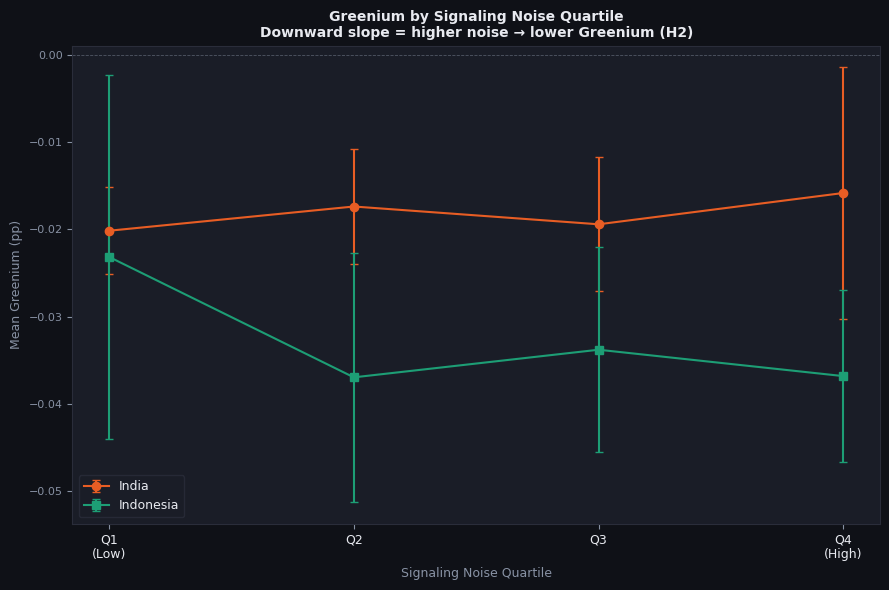

✓ Saved → ..\output\regression\plot4_noise_quartiles.png


In [23]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(BG); style_ax(ax)

p4 = panel.dropna(subset=['signaling_noise','greenium']).copy()
p4['noise_q'] = pd.qcut(p4['signaling_noise'], 4,
                         labels=['Q1\n(Low)','Q2','Q3','Q4\n(High)'])

for country, color, marker in [('India',ORANGE,'o'),('Indonesia',TEAL,'s')]:
    sub   = p4[p4['country']==country]
    means = sub.groupby('noise_q', observed=True)['greenium'].mean()
    cis   = sub.groupby('noise_q', observed=True)['greenium'].sem() * 1.96
    ax.errorbar(range(4), means.values, yerr=cis.values,
                marker=marker, color=color, linewidth=1.5, markersize=6,
                label=country, capsize=3)

ax.axhline(0, color=GRAY, linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_xticks(range(4))
ax.set_xticklabels(['Q1\n(Low)','Q2','Q3','Q4\n(High)'], color=WHITE, fontsize=9)
ax.set_xlabel('Signaling Noise Quartile', fontsize=9)
ax.set_ylabel('Mean Greenium (pp)', fontsize=9)
ax.set_title('Greenium by Signaling Noise Quartile\n'
             'Downward slope = higher noise → lower Greenium (H2)',
             fontsize=10, fontweight='bold', color=WHITE)
ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'plot4_noise_quartiles.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); print(f"✓ Saved → {out}")


---
# Part 7 — Save Outputs


In [24]:
# Save regression panel to a dedicated Output folder
OUTPUT_FOLDER = os.path.join(ROOT, 'output', 'regression')
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

csv_dir = os.path.join(ROOT, 'data', 'processed', 'regression')
os.makedirs(csv_dir, exist_ok=True)
out_csv = os.path.join(csv_dir, 'regression_panel.csv')
save_cols = ['date','country','tenor','pair_id','greenium','ytm_green','ytm_conv',
             'sentiment','signaling_noise','vix','cds','fx','post']
if 'sentiment_climatebert' in panel.columns:
    save_cols.append('sentiment_climatebert')

panel[save_cols].to_csv(out_csv, index=False)
print(f"✓ Panel saved → {out_csv}")
print(f"  Shape: {panel[save_cols].shape}")
print()
print("All outputs in:", OUTPUT_FOLDER)
print(f"Panel CSV:  {out_csv}")
print(f"Plot files: {OUTPUT_FOLDER}")
print("  ├── plot1_greenium_timeseries.png")

print("  ├── plot2_coefficients.png")
print("  ├── plot3_sentiment_scatter.png")
print("  └── plot4_noise_quartiles.png")

✓ Panel saved → ..\data\processed\regression\regression_panel.csv
  Shape: (1455, 14)

All outputs in: ..\output\regression
Panel CSV:  ..\data\processed\regression\regression_panel.csv
Plot files: ..\output\regression
  ├── plot1_greenium_timeseries.png
  ├── plot2_coefficients.png
  ├── plot3_sentiment_scatter.png
  └── plot4_noise_quartiles.png
